In [ ]:
df


# Exploratory Analysis of Electric Vehicle Specifications and Market Trends in Europe

# Problem Statement
The European electric vehicle market has grown rapidly, offering consumers a broad selection of vehicles with diverse capabilities, features, and performance levels. This increasing variety has made it difficult to assess how vehicles differ in terms of practicality, value, and overall market positioning. In addition, the competitive nature of the industry requires manufacturers to understand market dynamics, customer preferences, and emerging trends to maintain a strong presence. Therefore, there is a need to systematically examine the current EV landscape to identify patterns in vehicle offerings, brand presence, feature availability, and market distribution, enabling a better understanding of the factors shaping the European electric vehicle industry.


# Objective 
The objective of this project is to extract, clean, and analyze electric vehicle data collected from the EV Database using web scraping and data preprocessing techniques. The study aims to examine vehicle characteristics, manufacturer participation, availability trends, pricing patterns, and feature adoption across the European market. Through exploratory data analysis and visualization, the project seeks to uncover meaningful patterns, identify the key factors influencing vehicle value, compare different market categories, and generate actionable insights that support informed decision-making for consumers, manufacturers, and industry stakeholders.


# Key Business Questions
- What is the overall structure of the European electric vehicle market in terms of vehicle segments, drive types, seating capacity, and model availability?
- How do electric vehicles differ in key performance aspects such as driving range, energy efficiency, acceleration, and charging capability?
- Which manufacturers have the strongest market presence, and how are they positioned across different vehicle segments?
- How do vehicle prices vary across market segments and countries, and what factors contribute to these differences?
- How are technical characteristics such as range, weight, efficiency, charging performance, and safety ratings related to vehicle value?
- What trends can be observed in feature adoption, product lifecycle, and overall market evolution within the European EV industry?

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("cleaned_EV_Dataset3.csv")

In [6]:
df.columns

Index(['brand_name', 'model', 'efficiency(Wh/km)', 'real_Range(km)',
       'weight(kg)', 'acceleration(sec)', 'one_stop_range(km)',
       'fast_charge(kWh)', 'tow_weight(kg)', 'cargo_volume(L)',
       'price_per_range(€/km)', 'germany_price(euros)',
       'netherlands_price_(€)', 'uk_gbp', 'availability', 'start_period',
       'end_period', 'drive_type', 'market_segment', 'seats',
       'heat_pump_availability', 'towbar_possible', 'safety_rating'],
      dtype='object')

In [17]:
df.shape

(1350, 23)

In [18]:
df.head()

,brand_name,model,efficiency(Wh/km),real_Range(km),weight(kg),acceleration(sec),one_stop_range(km),fast_charge(kWh),tow_weight(kg),cargo_volume(L),...,uk_gbp,availability,start_period,end_period,drive_type,market_segment,seats,heat_pump_availability,towbar_possible,safety_rating
0,Tesla,Model 3 RWD,218,275,1847,6.2,331,60.0,1000,682,...,37990,Available,December 2025,Present,Rear,D,5,Yes,Yes,0
1,BMW,iX3 50 xDrive,279,390,2360,4.9,478,108.7,2000,578,...,58755,Available,September 2025,Present,All,D,5,Yes,Yes,0
2,MG,MG4 Electric 64 kWh,280,220,1726,7.9,249,61.7,500,363,...,29745,Discontinued,October 2022,February 2026,Rear,C,5,Yes,Yes,5
3,BMW,iX xDrive40,323,220,2440,6.1,237,71.0,2500,500,...,69905,Discontinued,October 2021,January 2025,All,E,5,Yes,Yes,5
4,Fiat,500e Hatchback 42 kWh,257,145,1365,9.0,162,37.3,0,185,...,23995,Available,November 2020,Present,Front,B,4,No,No,4


# Observations
- Categorical Columns: brand_name, model, availability, start_period, end_period, drive_type, market_segment, heat_pump_availability, towbar_possible
- Discrete Numeric Columns: seats, safety_rating
- Real Numeric Columns: efficiency(Wh/km), real_Range(km), weight(kg), acceleration(sec), one_stop_range(km), fast_charge(kWh), tow_weight(kg), cargo_volume(L), price_per_range(€/km), germany_price(euros), netherlands_price_(€)

  

In [19]:
df.columns

Index(['brand_name', 'model', 'efficiency(Wh/km)', 'real_Range(km)',
       'weight(kg)', 'acceleration(sec)', 'one_stop_range(km)',
       'fast_charge(kWh)', 'tow_weight(kg)', 'cargo_volume(L)',
       'price_per_range(€/km)', 'germany_price(euros)',
       'netherlands_price_(€)', 'uk_gbp', 'availability', 'start_period',
       'end_period', 'drive_type', 'market_segment', 'seats',
       'heat_pump_availability', 'towbar_possible', 'safety_rating'],
      dtype='object')

# Columns Description
- brand_name → Manufacturer name of the electric vehicle (e.g., Tesla, BMW, MG)
- model → Specific model name/variant of the EV (e.g., Model 3 RWD, iX3 50 xDrive)
- efficiency(Wh/km) → Energy consumed per kilometer (Watt-hour per km). Lower = more efficient vehicle
- real_Range(km) → Actual driving range of the EV on a full charge under real-world conditions
- acceleration(sec) → Time taken to reach a certain speed (usually 0–100 km/h). Lower = faster acceleration
- weight(kg) → Total vehicle weight in kilograms
- tow_weight(kg) → Maximum towing capacity of the vehicle (how much weight it can pull)
- one_stop_range(km) → Distance the vehicle can travel before needing a charging stop in long trips
- fast_charge(kWh) → Maximum fast charging power supported (higher = faster charging)
- uk_gbp → Price of the vehicle in  Pounds (£)
- availability → Whether the vehicle is currently available or discontinued
- start_period → Month/year when the model was launched
- end_period → Model discontinuation date or current status ("Present").
- drive_type → Vehicle drivetrain configuration (Front, Rear, or All-Wheel Drive).
- market_segment → Vehicle category/segment (e.g., B, C, D, E — based on size/class positioning)
- seats → Number of passenger seats in the vehicle
- heat_pump_availability → Whether the car has a heat pump system (Yes/No, improves energy efficiency in cold weather)
- towbar_possible → Indicates whether the vehicle supports towing (Yes/No)
- safety_rating → Vehicle safety score (higher rating indicates better safety performance)







In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1350 entries, 0 to 1349
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   brand_name              1350 non-null   object 
 1   model                   1350 non-null   object 
 2   efficiency(Wh/km)       1350 non-null   int64  
 3   real_Range(km)          1350 non-null   int64  
 4   weight(kg)              1350 non-null   int64  
 5   acceleration(sec)       1350 non-null   float64
 6   one_stop_range(km)      1350 non-null   int64  
 7   fast_charge(kWh)        1350 non-null   float64
 8   tow_weight(kg)          1350 non-null   int64  
 9   cargo_volume(L)         1350 non-null   int64  
 10  price_per_range(€/km)   1350 non-null   int64  
 11  germany_price(euros)    1350 non-null   int64  
 12  netherlands_price_(€)   1350 non-null   int64  
 13  uk_gbp                  1350 non-null   int64  
 14  availability            1350 non-null   

# Obseravtions
- No null values  found in the dataset

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.shape

(1350, 23)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1350 entries, 0 to 1349
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   brand_name              1350 non-null   object 
 1   model                   1350 non-null   object 
 2   efficiency(Wh/km)       1350 non-null   int64  
 3   real_Range(km)          1350 non-null   int64  
 4   weight(kg)              1350 non-null   int64  
 5   acceleration(sec)       1350 non-null   float64
 6   one_stop_range(km)      1350 non-null   int64  
 7   fast_charge(kWh)        1350 non-null   float64
 8   tow_weight(kg)          1350 non-null   int64  
 9   cargo_volume(L)         1350 non-null   int64  
 10  price_per_range(€/km)   1350 non-null   int64  
 11  germany_price(euros)    1350 non-null   int64  
 12  netherlands_price_(€)   1350 non-null   int64  
 13  uk_gbp                  1350 non-null   int64  
 14  availability            1350 non-null   

In [24]:
df.head()

,brand_name,model,efficiency(Wh/km),real_Range(km),weight(kg),acceleration(sec),one_stop_range(km),fast_charge(kWh),tow_weight(kg),cargo_volume(L),...,uk_gbp,availability,start_period,end_period,drive_type,market_segment,seats,heat_pump_availability,towbar_possible,safety_rating
0,Tesla,Model 3 RWD,218,275,1847,6.2,331,60.0,1000,682,...,37990,Available,December 2025,Present,Rear,D,5,Yes,Yes,0
1,BMW,iX3 50 xDrive,279,390,2360,4.9,478,108.7,2000,578,...,58755,Available,September 2025,Present,All,D,5,Yes,Yes,0
2,MG,MG4 Electric 64 kWh,280,220,1726,7.9,249,61.7,500,363,...,29745,Discontinued,October 2022,February 2026,Rear,C,5,Yes,Yes,5
3,BMW,iX xDrive40,323,220,2440,6.1,237,71.0,2500,500,...,69905,Discontinued,October 2021,January 2025,All,E,5,Yes,Yes,5
4,Fiat,500e Hatchback 42 kWh,257,145,1365,9.0,162,37.3,0,185,...,23995,Available,November 2020,Present,Front,B,4,No,No,4


In [25]:
df["brand_name"].unique()

array(['Tesla', 'BMW', 'MG', 'Fiat', 'CUPRA', 'Volvo', 'Mercedes-Benz',
       'Volkswagen', 'Skoda', 'Kia', 'Leapmotor', 'BYD', 'Changan',
       'Hyundai', 'XPENG', 'Toyota', 'Renault', 'Zeekr', 'Dongfeng',
       'Jaecoo', 'Dacia', 'Audi', 'GAC', 'Mazda', 'Subaru', 'Citroen',
       'Lotus', 'Omoda', 'Lucid', 'Honda', 'Suzuki', 'Mini', 'Opel',
       'Maxus', 'firefly', 'Nissan', 'Lynk&Co', 'Peugeot', 'Ford',
       'Rolls-Royce', 'Jeep', 'Polestar', 'Porsche', 'Hongqi', 'KGM',
       'GWM', 'Geely', 'Smart', 'TOGG', 'Lexus', 'Voyah', 'Alpine',
       'Mitsubishi', 'NIO', 'DS', 'Fisker', 'VinFast', 'Seres', 'Alfa',
       'Cadillac', 'Aiways', 'Abarth', 'Jaguar', 'Lightyear', 'Maserati',
       'SEAT', 'Lancia', 'ORA', 'SsangYong', 'Genesis', 'e.GO', 'Elaris',
       'Skywell', 'JAC', 'Sono'], dtype=object)

In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
df.shape

(1350, 23)

In [29]:
df.head()

,brand_name,model,efficiency(Wh/km),real_Range(km),weight(kg),acceleration(sec),one_stop_range(km),fast_charge(kWh),tow_weight(kg),cargo_volume(L),...,uk_gbp,availability,start_period,end_period,drive_type,market_segment,seats,heat_pump_availability,towbar_possible,safety_rating
0,Tesla,Model 3 RWD,218,275,1847,6.2,331,60.0,1000,682,...,37990,Available,December 2025,Present,Rear,D,5,Yes,Yes,0
1,BMW,iX3 50 xDrive,279,390,2360,4.9,478,108.7,2000,578,...,58755,Available,September 2025,Present,All,D,5,Yes,Yes,0
2,MG,MG4 Electric 64 kWh,280,220,1726,7.9,249,61.7,500,363,...,29745,Discontinued,October 2022,February 2026,Rear,C,5,Yes,Yes,5
3,BMW,iX xDrive40,323,220,2440,6.1,237,71.0,2500,500,...,69905,Discontinued,October 2021,January 2025,All,E,5,Yes,Yes,5
4,Fiat,500e Hatchback 42 kWh,257,145,1365,9.0,162,37.3,0,185,...,23995,Available,November 2020,Present,Front,B,4,No,No,4


# Univariate Visualizations for Numerical Columns

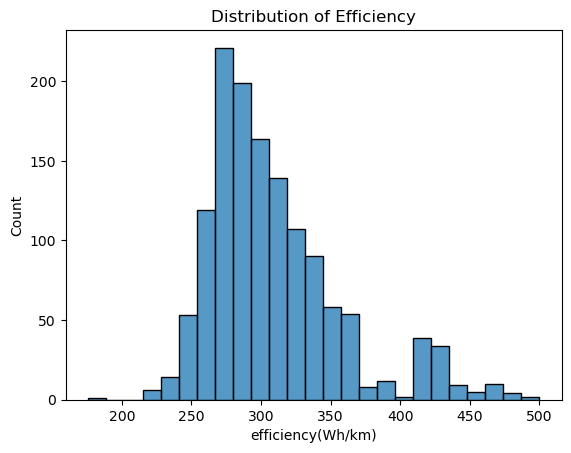

In [30]:
sns.histplot(df, x = "efficiency(Wh/km)", bins = 25)
plt.title("Distribution of Efficiency")
plt.show()
# plt.ylim(0,10)

In [31]:
df[df["efficiency(Wh/km)"]<200][["brand_name", "efficiency(Wh/km)"]]

,brand_name,efficiency(Wh/km)
594,Lightyear,176


# Observations

- Efficiency is Energy consumed per kilometer in watt-hours. Lower values indicate better efficiency.
- Higher value indicates less efficient vehicles
- The histogram shows that most of the EV   cars have an  effeciency range of 260-300 wh/km which indicates moderate consumption among most vehicles
- There is only one car less than 200 wh/km
- LightYear Brand car have 176 efficiency wh/km which is less than 200
- There are few vehicles which has higher energy usage

Text(0.5, 1.0, 'Histogram of Real Range(km)')

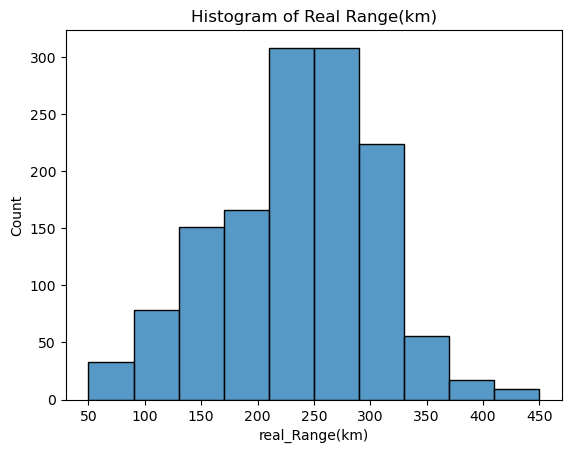

In [32]:
sns.histplot(df, x = "real_Range(km)", bins = 10)
plt.title("Histogram of Real Range(km)")

# Obseravtions 
- Real range is distance(km) an electric car can travel on one full charge under realistic driving conditoins (traffic, weather)
- This metric is used to determine a car's daily driving capability
- There are more number of cars whose driving range in between 210 and 290 km which indicates that mid range electric vehicles are dominant in the market 

Text(0.5, 1.0, 'Distribution of One Stop Range(km)')

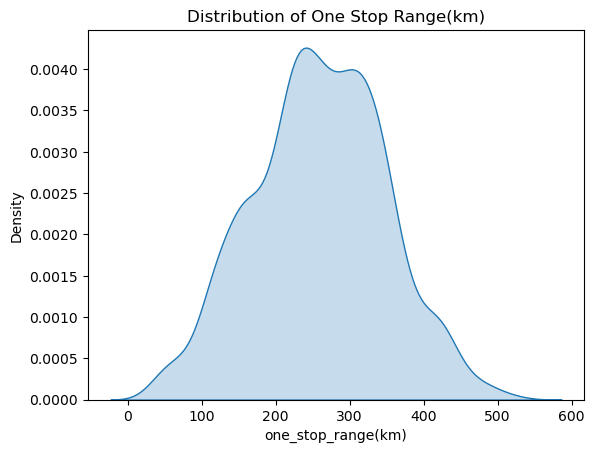

In [33]:
sns.kdeplot(df, x = "one_stop_range(km)", fill = True)
plt.title("Distribution of One Stop Range(km)")

# Observations
- The maximum distance can cover with one fast charging stop
- one stop range is metric is useful for long distance travel performance
- One-stop range is the maximum distance possible with one fast-charge top-up. The KDE shows a right-skewed distribution, meaning most vehicles can cover moderate long-distance trips but few can cover very long journeys in one stop.

Text(0.5, 1.0, 'Box Plot of Acceleration')

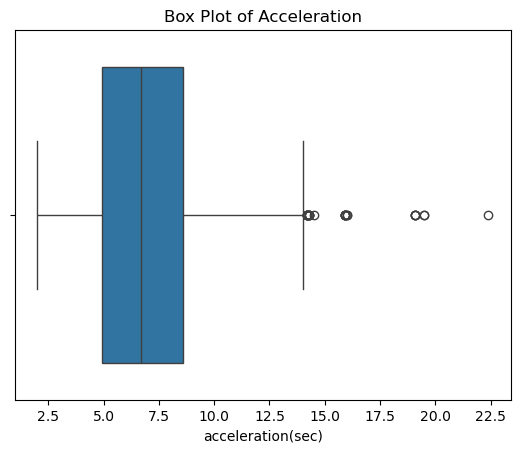

In [34]:
sns.boxplot(df, x = "acceleration(sec)")
plt.title("Box Plot of Acceleration")

# Obseravtions
- Time required to accelerate from 0–100 km/h. Lower values mean faster acceleration.
- It measures how quickly the electric car gains speed
- Median is approximately equal to 7 sec and 50% of the cars have acceleration in between 5sec to 9 sec appoxiamtely
- There are no cars which have acceleration less than 2
- There are few outliers which indicates that few cars have acceleration more than the maximum value which is upper whisker

# Univariate Analysis of Categorical columns

In [35]:
brand_cars = df["brand_name"].value_counts().head(10)

Text(0.5, 1.0, 'Top 10 Brands with Higest  Number of EV Models')

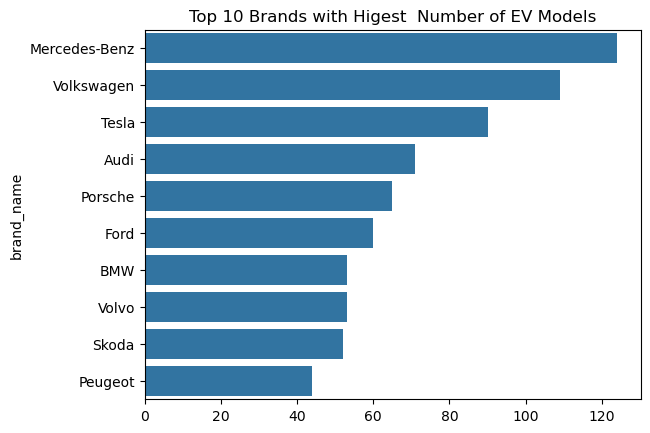

In [36]:
sns.barplot(x = brand_cars.values, y = brand_cars.index)
plt.title("Top 10 Brands with Higest  Number of EV Models")

# Obseravtions
- Mercedes-Benz appears as the top manufacturer in terms of the number of electric vehicle models, indicating a strong and diverse EV lineup

In [37]:
available_types = df["availability"].value_counts()

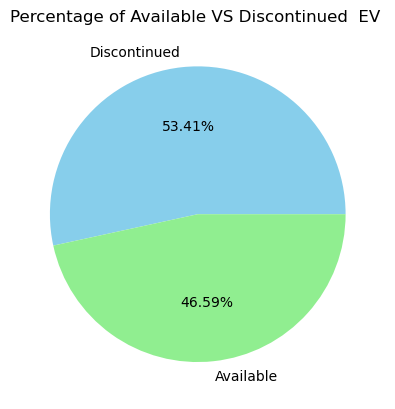

In [38]:
plt.pie(
    available_types.values,
    labels=available_types.index,
    autopct="%0.2f%%",
    colors=["skyblue", "lightgreen"]
)

plt.title("Percentage of Available VS Discontinued  EV ")
plt.show()

# Obseravtions
- Discontinued electric vehicle models constitute the largest share of the dataset, accounting for 53% of all vehicles, while currently available models represent 47%. This indicates that more than half of the EV models included in the dataset are no longer actively marketed.

Text(0.5, 1.0, 'EV Distribution by Market Segment')

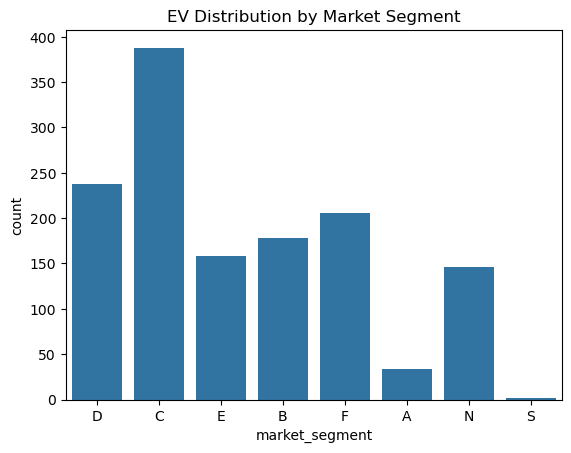

In [39]:
sns.countplot(df, x = "market_segment")
plt.title("EV Distribution by Market Segment")

# Observations
- Vehicle classification based on size and purpose
- A - Mini
- B - Compact
- C - Medium
- D - Large
- E - Executive
- F - Luxury
- N - Passenger Van
- S - Sports
- Segment C (Medium) has the highest number of models, making it the dominant category. Sports (S) segment has the fewest models, confirming EVs are primarily practical rather than performance-oriented in Europe.

In [40]:
drive_counts = df["drive_type"].value_counts()

Text(0.5, 1.0, 'Proportion of vehicles by Drive Type')

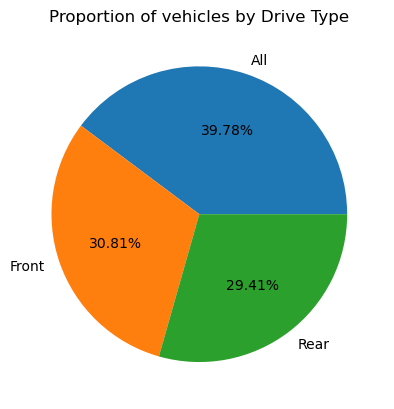

In [41]:
plt.pie(drive_counts.values, labels = drive_counts.index, autopct = "%0.2f%%")
plt.title("Proportion of vehicles by Drive Type")

# Observations
- Drive type proportions show the split between front, rear, and all-wheel drive — front-wheel drive being most common for mid-range vehicles, all-wheel drive for performance and executive segments.

In [42]:
seat_count = df["seats"].value_counts()

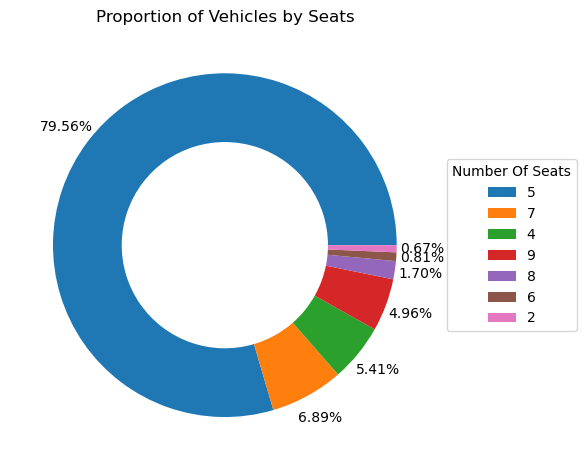

In [43]:
plt.pie(x = seat_count.values, autopct = "%0.2f%%", pctdistance = 1.15, wedgeprops = {'width':0.4})
plt.legend(labels = seat_count.index,
          title = "Number Of Seats",
          loc = "center left",
          bbox_to_anchor = (1,0.5))
plt.title("Proportion of Vehicles by Seats")
plt.tight_layout()

# Observations
- Five-seat vehicles represent the majority of EV models.
- Vehicles with larger seating capacities occupy a smaller share.


# Bivariate Analysis

In [44]:
df.columns

Index(['brand_name', 'model', 'efficiency(Wh/km)', 'real_Range(km)',
       'weight(kg)', 'acceleration(sec)', 'one_stop_range(km)',
       'fast_charge(kWh)', 'tow_weight(kg)', 'cargo_volume(L)',
       'price_per_range(€/km)', 'germany_price(euros)',
       'netherlands_price_(€)', 'uk_gbp', 'availability', 'start_period',
       'end_period', 'drive_type', 'market_segment', 'seats',
       'heat_pump_availability', 'towbar_possible', 'safety_rating'],
      dtype='object')

Text(0.5, 1.0, 'Weight VS Energy Consumption')

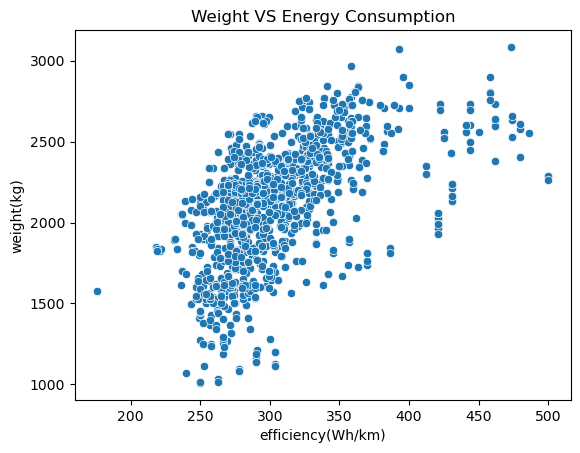

In [45]:
sns.scatterplot(df, x = "efficiency(Wh/km)" , y = "weight(kg)")
plt.title("Weight VS Energy Consumption")

# Observations
- Energy consumption tends to increase as vehicle weight increases.
- Heavier vehicles require more energy to operate.
- This demonstrates the importance of vehicle weight in determining efficiency.


Text(0.5, 1.0, 'Relationship Between Purchase Price in UK and Charging Performance')

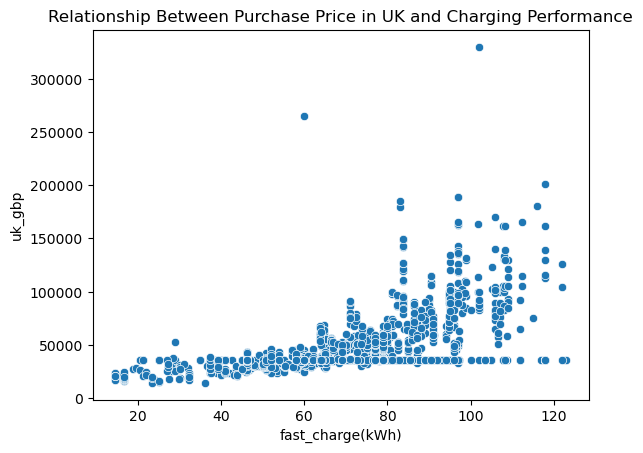

In [46]:
sns.scatterplot(df, x = "fast_charge(kWh)", y = "uk_gbp")
plt.title("Relationship Between Purchase Price in UK and Charging Performance")

# Observations
- Vehicles with higher charging capability generally command higher prices.
- Premium EVs often include faster charging technology.
- Charging performance appears to be an important pricing factor.


Text(0.5, 1.0, 'Regression Plot of EV Prices in Germany and Netharlands')

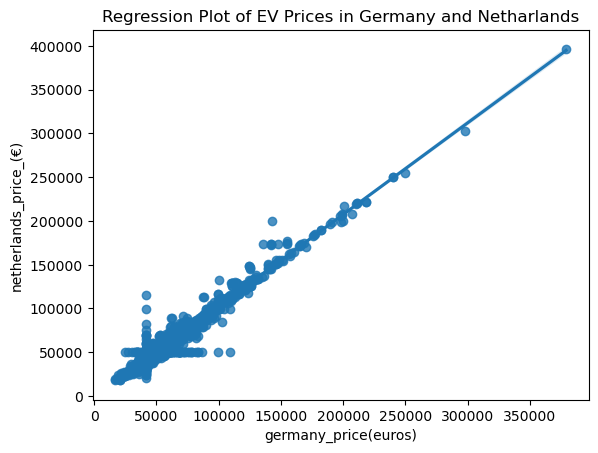

In [47]:
sns.regplot(
    data=df,
    x='germany_price(euros)',
    y='netherlands_price_(€)'
)
plt.title("Regression Plot of EV Prices in Germany and Netharlands")

# Observations
- Prices in both countries exhibit a strong positive relationship.
- Vehicles that are expensive in Germany are generally expensive in the Netherlands.
- Pricing strategies appear relatively consistent across European markets.


# Categorical VS numerical

In [48]:
avg_price_segment = df.groupby("market_segment")["uk_gbp"].mean()
avg_price_segment

market_segment
A    22017.794118
B    32242.449438
C    41051.463918
D    51039.180672
E    63564.082278
F    86745.995146
N    41504.863014
S    57745.000000
Name: uk_gbp, dtype: float64

Text(0.5, 1.0, 'Comparison of Average EV Prices by Market Segment')

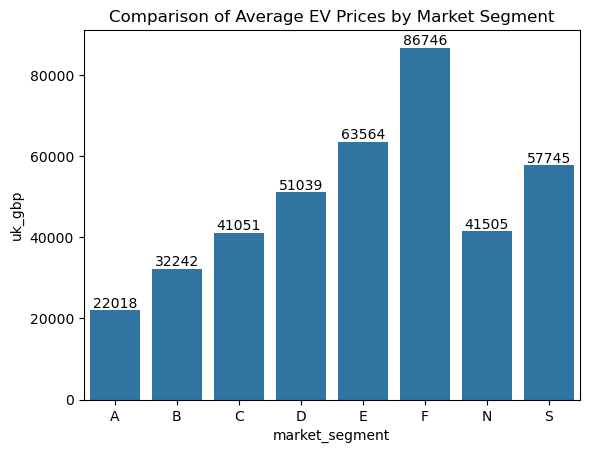

In [49]:
ax = sns.barplot(avg_price_segment)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')


plt.title("Comparison of Average EV Prices by Market Segment")

# Observations
- F (Luxury) and E (Executive) segments command the highest average prices.
- B (Compact) and C (Medium) segments are most affordable.
- Market positioning strongly influences vehicle pricing.


Text(0.5, 1.0, 'Distribution of Real Driving Range Across Market Segment')

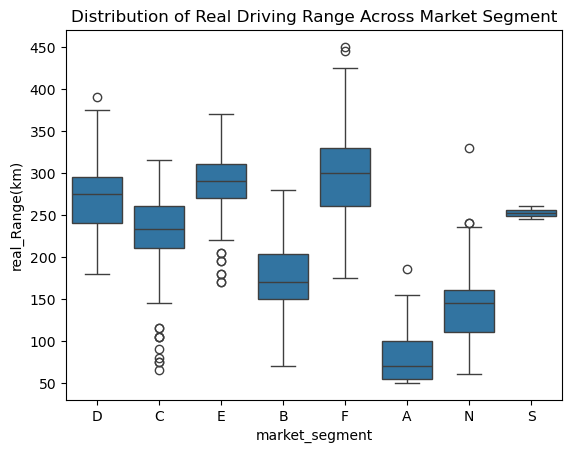

In [50]:
sns.boxplot(df, x = "market_segment", y = "real_Range(km)")
plt.title("Distribution of Real Driving Range Across Market Segment")

# Observations
- Premium segments generally offer higher driving ranges.
- Lower-priced segments tend to have more limited range capabilities.
  


In [68]:
discontinued = df[df['end_period'] != 'Present'].copy()

discontinued['discontinued_year'] = discontinued['end_period'].str.extract(r'(\d{4})')

yearly_counts = discontinued['discontinued_year'].value_counts().sort_index()

print(yearly_counts)

discontinued_year
2013      1
2015      2
2016     18
2017     12
2018     13
2019     25
2020     20
2021     44
2022     59
2023    108
2024    152
2025    171
2026     96
Name: count, dtype: int64


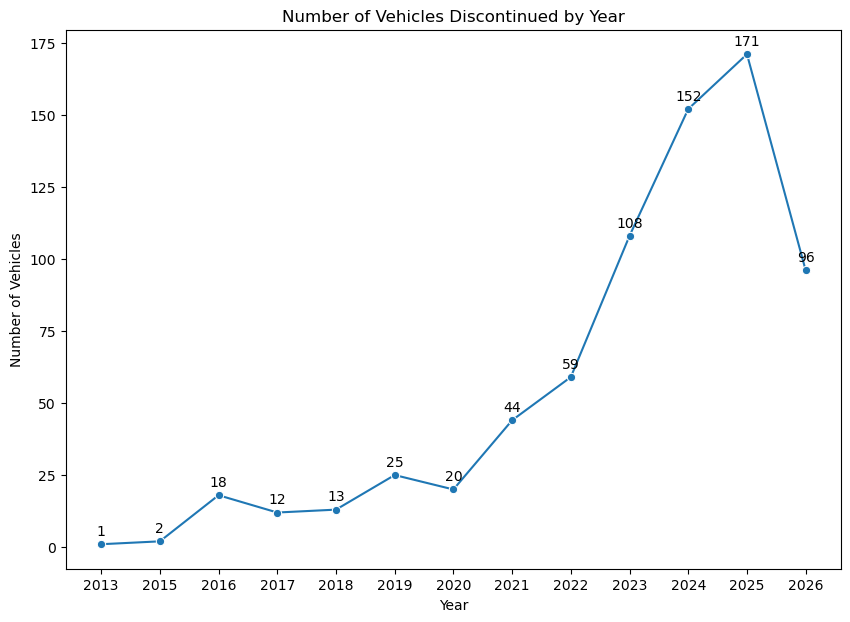

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

ax = sns.lineplot(
    x=yearly_counts.index,
    y=yearly_counts.values,
    marker='o'
)

# Add data labels
for x, y in zip(yearly_counts.index, yearly_counts.values):
    ax.text(x, y+2, str(y), ha='center', va='bottom')

plt.title('Number of Vehicles Discontinued by Year')
plt.xlabel('Year')
plt.ylabel('Number of Vehicles')
plt.xticks(rotation=0)

plt.show()

# Observations
- Discontinuation activity varies across years.
- Peaks may indicate technological transitions or model replacements.
- Years with high discontinuation likely correspond to major platform transitions in the EV industry.

# Categorical vs categorical

In [53]:
ct = pd.crosstab(df["market_segment"], df["brand_name"])

In [54]:
ct.idxmax(axis  = 1)

market_segment
A            Smart
B          Renault
C       Volkswagen
D            Tesla
E    Mercedes-Benz
F          Porsche
N       Volkswagen
S               MG
dtype: object

In [55]:
result = pd.DataFrame({
    'Top_Segment': ct.idxmax(axis = 1),
    'Count': ct.max(axis = 1)
}).reset_index()

print(result)

  market_segment    Top_Segment  Count
0              A          Smart      9
1              B        Renault     16
2              C     Volkswagen     59
3              D          Tesla     41
4              E  Mercedes-Benz     40
5              F        Porsche     50
6              N     Volkswagen     25
7              S             MG      2


In [56]:
result.columns

Index(['market_segment', 'Top_Segment', 'Count'], dtype='object')

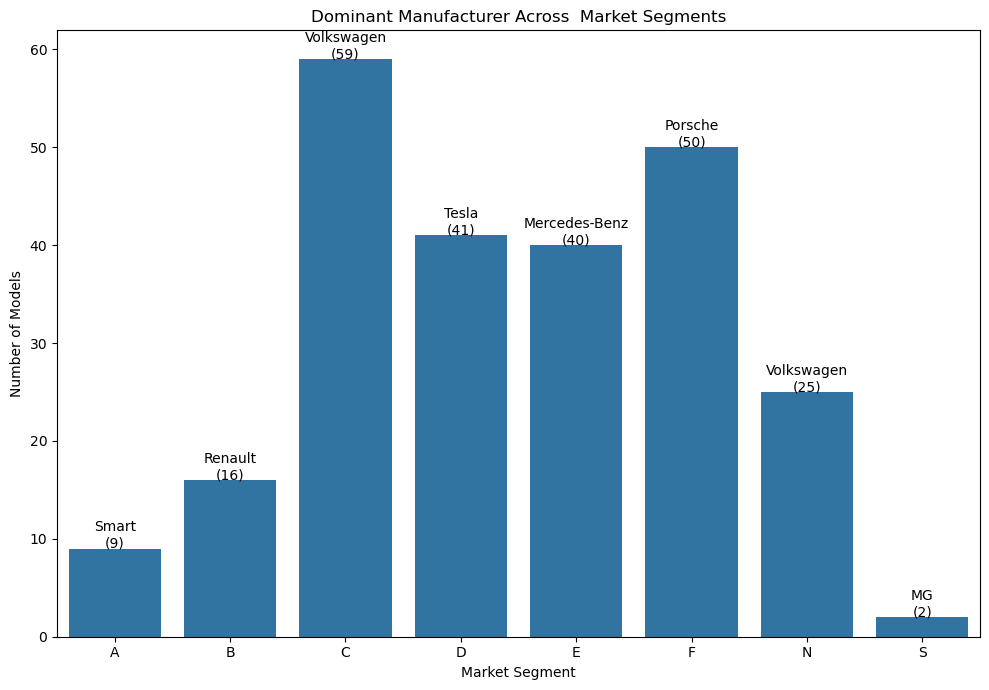

In [57]:
plt.figure(figsize=(10,7))
ax = sns.barplot(
    data=result,
    x='market_segment',
    y='Count',
    errorbar=None)
# Brand name + count on bars
for i, row in result.iterrows():
    ax.text(
        i,
        row['Count'] + 0.1,
        f"{row['Top_Segment']}\n({row['Count']})",
        ha='center')
plt.title('Dominant Manufacturer Across  Market Segments')
plt.xlabel('Market Segment')
plt.ylabel('Number of Models')
plt.tight_layout()
plt.show()

# Observations
- Different brands lead different segments, revealing that clear  brand-to-segment specialisation. Some manufacturers dominate affordable segments while others lead premium one


Text(0.5, 1.0, 'Distribution of Drive Types Across Market Segments')

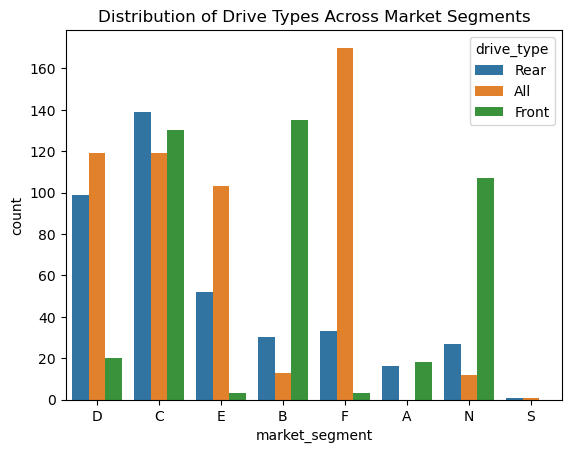

In [58]:
sns.countplot(df, x = "market_segment", hue = "drive_type")
plt.title("Distribution of Drive Types Across Market Segments")

# Observations
- AWD (All-Wheel Drive) is more prevalent in upper segments (D, E, F, S).
- segments (A, B, C) are dominated by front-wheel drive.

# Multi Variate Analysis

Text(0.5, 1.0, 'Comparison of EV Prices Across Safety Ratings and Drive Types')

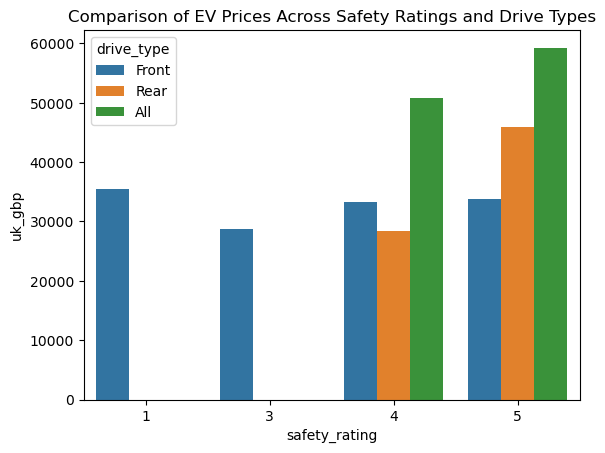

In [59]:
df_rating = df[df["safety_rating"] != 0]
sns.barplot(df_rating, x = "safety_rating", y = "uk_gbp", hue = "drive_type", errorbar = None)
plt.title("Comparison of EV Prices Across Safety Ratings and Drive Types")


# Observations
- Higher safety-rated vehicles generally command higher prices.
- AWD vehicles with top safety ratings are the most expensive.
- while front-wheel drive vehicles at similar safety ratings are cheaper - confirming drive type and safety together as price signals.

In [60]:
result = df.groupby('market_segment').agg(
    HeatPump_Percentage=('heat_pump_availability',
                         lambda x: (x == 'Yes').mean() * 100),
    Towbar_Percentage=('towbar_possible',
                       lambda x: (x == 'Yes').mean() * 100)
).reset_index()

print(result)

  market_segment  HeatPump_Percentage  Towbar_Percentage
0              A             5.882353           0.000000
1              B            69.662921          47.752809
2              C            92.268041          77.319588
3              D            81.512605          90.336134
4              E            99.367089          96.202532
5              F            70.873786          47.572816
6              N            73.972603          84.931507
7              S             0.000000           0.000000


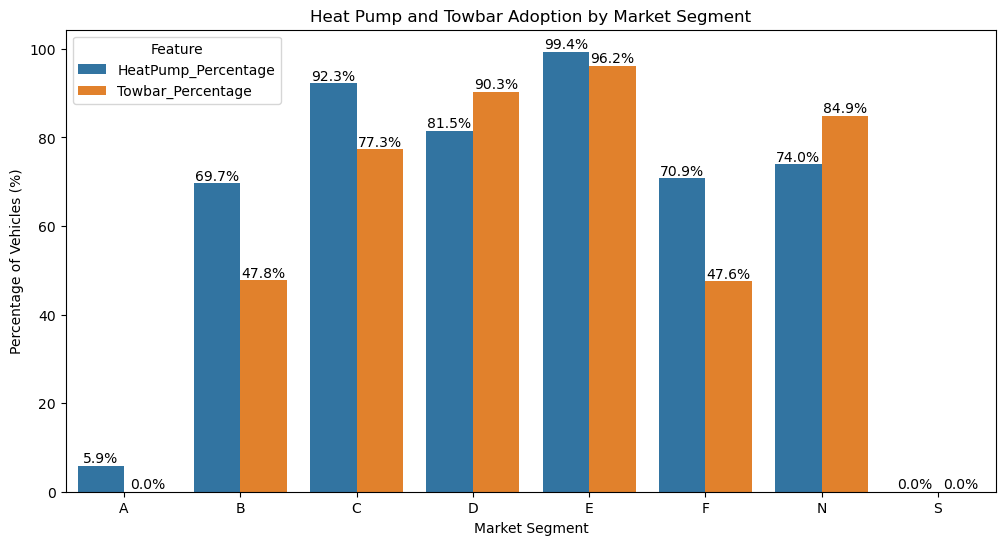

In [61]:
plot_df = result.melt(
    id_vars='market_segment',
    var_name='Feature',
    value_name='Percentage'
)

plt.figure(figsize=(12,6))
ax = sns.barplot(
    data=plot_df,
    x='market_segment',
    y='Percentage',
    hue='Feature',
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.ylabel('Percentage of Vehicles (%)')
plt.xlabel('Market Segment')
plt.title('Heat Pump and Towbar Adoption by Market Segment')
plt.show()

# Obseravtions
- Heat pump adoption increases in upper segments (D, E, F), indicating it is positioned as a premium efficiency feature.
- Towbar availability is notably higher in N (Passenger Van) segment.

Text(0.5, 1.0, 'EV Featrure Correlation Analysis')

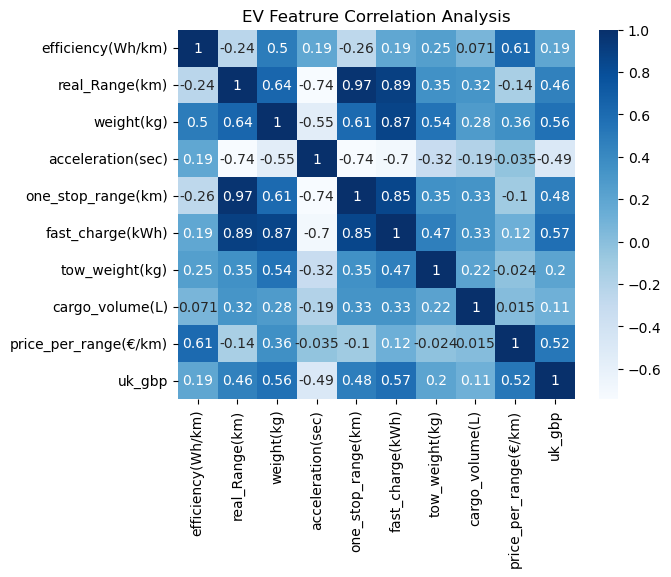

In [62]:
selected_cols = df[["efficiency(Wh/km)","real_Range(km)","weight(kg)", "acceleration(sec)","one_stop_range(km)","fast_charge(kWh)","tow_weight(kg)","cargo_volume(L)","price_per_range(€/km)","uk_gbp"]]
sns.heatmap(selected_cols.corr(), annot = True, cmap = "Blues")
plt.title("EV Featrure Correlation Analysis")

# Obseravtions
- Real range and one-stop range are strongly positively correlated.
- Efficiency (Wh/km) is negatively correlated with range — higher consumption means shorter range.
- Weight is positively correlated with fast-charge capacity and price. Price per range is a useful composite metric reflecting value efficiency.
- Range, charging performance, and vehicle weight are among the strongest drivers of EV pricing.


In [63]:
df['uk_eur'] = df['uk_gbp'] * 1.16   # Example rate

In [64]:
z_long = df[['germany_price(euros)','netherlands_price_(€)','uk_gbp']].melt(
    var_name='Country',
    value_name='Price'
)

Text(0.5, 1.0, 'Price Distribution Among Countries')

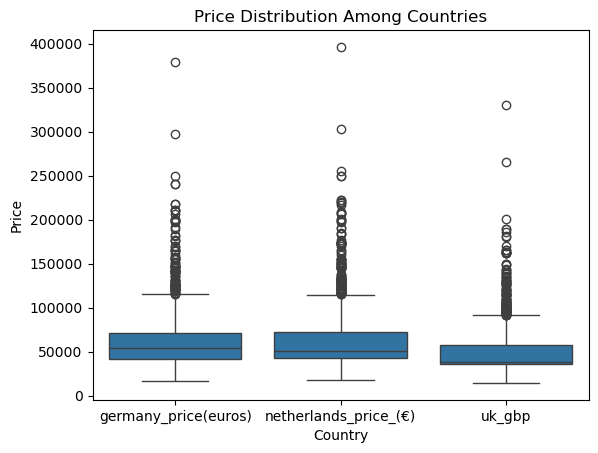

In [65]:
sns.boxplot(
    data=z_long,
    x='Country',
    y='Price'
)
plt.title("Price Distribution Among Countries")

# Observations
- Price distributions across Germany, Netherlands, and UK are broadly similar in median and spread.
- UK prices are slightly different in spread, possibly due to exchange rate adjustment. 


In [66]:
df.columns

Index(['brand_name', 'model', 'efficiency(Wh/km)', 'real_Range(km)',
       'weight(kg)', 'acceleration(sec)', 'one_stop_range(km)',
       'fast_charge(kWh)', 'tow_weight(kg)', 'cargo_volume(L)',
       'price_per_range(€/km)', 'germany_price(euros)',
       'netherlands_price_(€)', 'uk_gbp', 'availability', 'start_period',
       'end_period', 'drive_type', 'market_segment', 'seats',
       'heat_pump_availability', 'towbar_possible', 'safety_rating', 'uk_eur'],
      dtype='object')

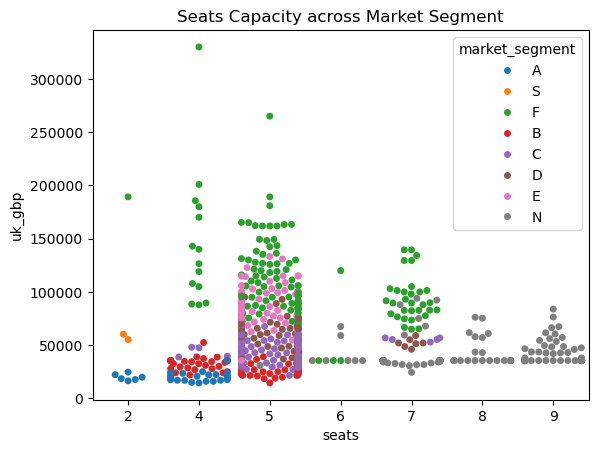

In [67]:
import warnings
warnings.filterwarnings("ignore")
sns.swarmplot(df, x = "seats", y = "uk_gbp", hue = "market_segment")
plt.title("Seats Capacity across Market Segment")
plt.show()

# Observations
- Most segments are dominated by five-seat configurations.
- Larger seating capacities are generally associated with larger vehicle categories


# Key Insights
- Most EV models are concentrated in the mid-range category, offering a balance between driving range, efficiency, and affordability.
- Vehicle segment has a strong impact on pricing, with premium and luxury categories commanding significantly higher prices than compact and mid-sized vehicles.
- Segment C is the most competitive market segment, containing the highest number of electric vehicle models and manufacturer participation.
- Vehicles with longer driving ranges and faster charging capabilities tend to be priced higher, highlighting the value consumers place on convenience and performance.
- Energy consumption generally increases with vehicle weight, indicating that heavier vehicles require more power to operate efficiently.
- A large number of EV models have been discontinued, reflecting continuous product updates and changing market demands.
- Advanced features such as heat pumps, towing capability, and higher safety ratings are more common in higher-end vehicles, contributing to their market positioning and value.






# Recommendations
- Manufacturers should focus on improving efficiency and reducing vehicle weight to enhance range and overall performance.
- Expand fast-charging capabilities across more vehicle segments to improve convenience and customer satisfaction.
- Prioritize innovation in highly competitive segments, particularly Segment C, where consumer demand is strongest.
- Consumers should evaluate EVs based on overall value, considering range, charging capability, efficiency, safety, and price together.
- Industry stakeholders should continue investing in charging infrastructure to support the growing adoption of electric vehicles.

# Conclusion
The analysis of the European electric vehicle market demonstrates how vehicle characteristics, market segments, manufacturer strategies, and feature availability influence overall vehicle value and positioning. Key factors such as driving range, charging capability, efficiency, and vehicle segment play an important role in differentiating EV models and shaping pricing patterns. The findings provide a comprehensive view of the market landscape and offer valuable insights that can support informed decision-making for consumers, manufacturers, and other industry stakeholders.